In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imbami import DensityDistanceRelevance, DensityRatioRelevance, apply_csmogn, apply_crbsmogn, relevance_function_factory, sampling_factory
from scipy.stats import gaussian_kde
from ruamel.yaml import YAML

plt.rcParams.update({
    'font.size': 8,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
})

# Dual-Source Relevance Functions

Example with non-uniform domain priority distribution.

In [2]:
# create dataset with two continuous and one categorical variable.
np.random.seed(1)
numerical_data = pd.DataFrame(data = np.random.normal(size = (1000,2)), columns = ['num1', 'num2'])
categorical_data = pd.DataFrame(data = np.random.choice([1,2], size=1000), columns= ['cat1'])
categorical_data = categorical_data.astype('category')
data = pd.concat([numerical_data, categorical_data], axis = 1)
data

,num1,num2,cat1
0,1.624345,-0.611756,2
1,-0.528172,-1.072969,2
2,0.865408,-2.301539,1
3,1.744812,-0.761207,1
4,0.319039,-0.249370,1
...,...,...,...
995,-0.430770,0.944285,2
996,-0.472876,-1.407064,1
997,-0.447473,0.188583,2
998,0.560918,-0.921659,1


In [3]:
yfeature = 'num1'
min_val=data[yfeature].min()
max_val=data[yfeature].max()

In [4]:
class linear_rise:
    def __init__(self, min_val, max_val, floor=1e-6) -> None:
        self.min_val = min_val
        self.max_val = max_val
        self.floor = floor

    def __call__(self, x):
        x = np.asarray(x, dtype=float)
        # Start with the floor value everywhere
        result = np.full_like(x, fill_value=self.floor)

        # Linear rise only inside the interval
        mask = (x >= self.min_val) & (x <= self.max_val)
        a = 2 / (self.max_val - self.min_val)**2
        b = -2 * self.min_val / (self.max_val - self.min_val)**2
        result[mask] = a * x[mask] + b + 1e-12

        return result

In [5]:
# Calculate KDE
data_pdf = gaussian_kde(data[yfeature], bw_method='silverman') 

domain_space = np.linspace(min_val, max_val, 1000)
domain_pdf = linear_rise(min_val=min_val, max_val=max_val)
domain_relevance = domain_pdf(domain_space)
data_relevance = pd.Series(data_pdf(domain_space))

bin_edges = np.histogram_bin_edges(data[yfeature], bins=30, range=(min_val, max_val))


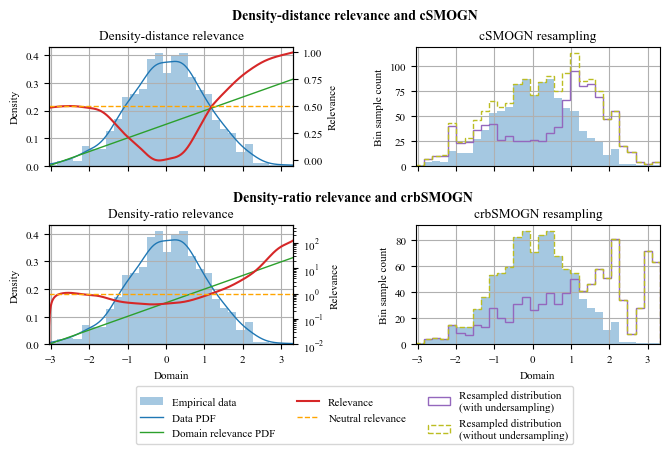

In [6]:
# Create subplots with shared x-axis but separate y-axes
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(6.5, 3.5), sharex=True, sharey=False)

# Top row plots
# Left: Plot data distribution and PDFs
ax1.hist(data[yfeature], bins=bin_edges, density=True, alpha=0.4, color='tab:blue', label='Empirical data')
ax1.plot(domain_space, data_relevance, color='tab:blue', linewidth=1, linestyle= '-', label='Data PDF')
ax1.plot(domain_space, domain_relevance, color='tab:green', linewidth=1, label='Domain relevance PDF')
# Calculate and plot density-distance relevance
relv_function = DensityDistanceRelevance(emp_density_mode='provide_pdf', domain_density_mode='provide_pdf')
relv_function.fit(data = None,
        emp_pdf=data_pdf,
        domain_pdf=domain_pdf)
relevance_space = relv_function.eval(domain_space)
ax1_twin = ax1.twinx()
ax1_twin.plot(domain_space, relevance_space, color='tab:red', linewidth=1.5, label='Relevance')
ax1_twin.axhline(y=0.5, color='orange', linestyle='--', linewidth=1, label='Neutral relevance')

ax1_twin.set_ylabel('Relevance')
ax1.set_title('Density-distance relevance')
ax1.set_ylabel('Density')
ax1.set_xlim(min_val, max_val)
ax1.grid(True)

# Right plot: Sampled histograms
# Original data
ax2.hist(data[yfeature], bins=bin_edges, density=False, alpha=0.4, color='tab:blue', label='Empirical data')
# Sample data
relevance_values = pd.Series(relv_function.eval(data[yfeature].to_numpy()), index = data.index)
data_csmogn_u = apply_csmogn(data=data, target_column= yfeature, relevance_values=relevance_values, enable_undersampling=True)
data_csmogn = apply_csmogn(data=data, target_column= yfeature, relevance_values=relevance_values, enable_undersampling=False)
ax2.hist(data_csmogn_u[yfeature], bins=bin_edges, density=False, alpha=1, color='tab:purple', 
         label='Resampled distribution\n(with undersampling)', histtype='step', linewidth=1)
ax2.hist(data_csmogn[yfeature], bins=bin_edges, density=False, alpha=1, color='tab:olive', 
         label='Resampled distribution\n(without undersampling)', histtype='step', linewidth=1, linestyle='--')
ax2.set_title('cSMOGN resampling')
ax2.set_ylabel('Bin sample count')
ax2.grid(True)



# Bottom row plots
# Left: Plot data distribution and PDFs
ax3.hist(data[yfeature], bins=bin_edges, density=True, alpha=0.4, color='tab:blue', label='Empirical data')
ax3.plot(domain_space, data_relevance, color='tab:blue', linewidth=1, linestyle= '-', label='Data PDF')
ax3.plot(domain_space, domain_relevance, color='tab:green', linewidth=1, label='Domain relevance PDF')

# Calculate and plot density-ratio relevance
relv_function = DensityRatioRelevance(emp_density_mode='provide_pdf', domain_density_mode='provide_pdf')
relv_function.fit(data = None,
        emp_pdf=data_pdf,
        domain_pdf=domain_pdf)
relevance_space = relv_function.eval(domain_space)
ax3_twin = ax3.twinx()
ax3_twin.plot(domain_space, relevance_space, color='tab:red', linewidth=1.5, label='Relevance')
ax3_twin.axhline(y=1, color='orange', linestyle='--', linewidth=1, label='Neutral relevance')
ax3_twin.set_yscale('log')

ax3_twin.set_ylabel('Relevance')
ax3_twin.set_ylim(1e-2,)
ax3.set_title('Density-ratio relevance')
ax3.set_xlabel('Domain')
ax3.set_ylabel('Density')
ax3.set_xlim(min_val, max_val)
ax3.grid(True)

# Right plot: Sampled histograms
# Original data
ax4.hist(data[yfeature], bins=bin_edges, density=False, alpha=0.4, color='tab:blue', label='Empirical data')
# Sample data
relevance_values = pd.Series(relv_function.eval(data[yfeature].to_numpy()), index = data.index)
data_crbsmogn_u = apply_crbsmogn(data=data, target_column= yfeature, relevance_values=relevance_values, enable_undersampling=True)
data_crbsmogn = apply_crbsmogn(data=data, target_column= yfeature, relevance_values=relevance_values, enable_undersampling=False)
ax4.hist(data_crbsmogn_u[yfeature], bins=bin_edges, density=False, alpha=1, color='tab:purple',
         label='Resampled distribution\n(with undersampling)', histtype='step', linewidth=1)
ax4.hist(data_crbsmogn[yfeature], bins=bin_edges, density=False, alpha=1, color='tab:olive',
         label='Resampled distribution\n(without undersampling)', histtype='step', linewidth=1, linestyle='--')
ax4.set_title('crbSMOGN resampling')
ax4.set_xlabel('Domain')
ax4.set_ylabel('Bin sample count')
ax4.grid(True)

# Combine legends into one
handles1, labels1 = ax1.get_legend_handles_labels()
handles1t, labels1t = ax1_twin.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
handles3t, labels3t = ax3_twin.get_legend_handles_labels()
handles4, labels4 = ax4.get_legend_handles_labels()

all_handles = handles1 + handles1t + handles2 + handles3 + handles3t + handles4
all_labels = labels1 + labels1t + labels2 + labels3 + labels3t + labels4

# Remove duplicate labels while preserving order
seen = set()
unique_handles = []
unique_labels = []
for handle, label in zip(all_handles, all_labels):
    if label not in seen:
        seen.add(label)
        unique_handles.append(handle)
        unique_labels.append(label)

# Position legend below the plots, centered
fig.legend(
    unique_handles,
    unique_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=3
)

# fig.suptitle('Density-distance and cSMOGN')
fig.text(0.5, ax1.get_position().y1 + 0.15, "Density-distance relevance and cSMOGN", ha="center", fontsize=10, fontweight="bold")
fig.text(0.5, ax3.get_position().y1 + 0.05, "Density-ratio relevance and crbSMOGN ", ha="center", fontsize=10, fontweight="bold")
# Adjust layout and show plot
fig.tight_layout(pad=0.0)
fig.subplots_adjust(left=0.03, right=0.97, wspace=0.5, hspace=0.5)

# Comparison of mitigation methods

Scenario with multiple sampling based mitigation methods.

In [7]:
yaml = YAML()
with open('scenarios.yml') as f:
    scenarios = yaml.load(f)

In [8]:
sampled_data = {}
sampled_data['base'] = data[yfeature]
for experiment_name, experiment_properties in scenarios.items():
    relevance_config = experiment_properties['relevance_config']
    sampling_config = experiment_properties['mitigation_config']
    if relevance_config['relevance_type'] in ('density_distance', 'density_ratio'):
        relevance_config['domain_data'] = data[yfeature].to_numpy()

    sample_relevance = relevance_function_factory(target_column = yfeature,
                                                data = data[yfeature].to_numpy(),
                                                **relevance_config)(data[yfeature].to_numpy())
    sample_relevance = pd.Series(sample_relevance, index=data.index)


 
    new_data = sampling_factory(data= data,
                                target_column= yfeature,
                                relevance_values=sample_relevance,
                                **sampling_config)
    sampled_data[experiment_name] = new_data[yfeature] # true values of the oversampled data

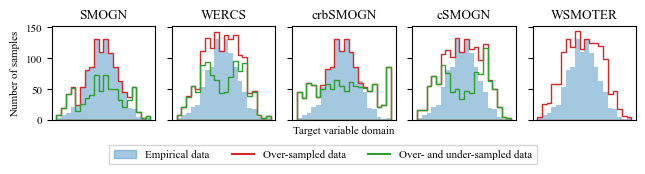

In [9]:
cmap = plt.colormaps['tab10']
hist_color = 'tab:blue'
undersample_color = 'tab:green'
sample_color = 'tab:red'

text_height = 0.9
text_left = 0.1
text_right = 0.9

# Create a single plot using subplots with 1x1 grid
fig, axs = plt.subplots(1,5, figsize=(6.5, 1.5), sharey= True)
for ax in axs:
    ax.hist(sampled_data['base'], density = False, alpha = 0.4, bins = 20, fill = True, histtype="stepfilled", color = hist_color, label = 'base')

name = 'smogn_intpol'
axs[0].set_title('SMOGN')
axs[0].hist(sampled_data[name], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = sample_color, label = name)
axs[0].hist(sampled_data[name + '_u'], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = undersample_color, label = name +'_u' )

name = 'wercs_intpol'
axs[1].set_title('WERCS')
axs[1].hist(sampled_data[name], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = sample_color, label = name)
axs[1].hist(sampled_data[name + '_u'], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = undersample_color, label = name +'_u' )

name = 'crbsmogn_drr'
axs[2].set_title('crbSMOGN')
axs[2].hist(sampled_data[name], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = sample_color, label = name)
axs[2].hist(sampled_data[name + '_u'], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = undersample_color, label = name +'_u' )

name = 'csmogn_ddr'
axs[3].set_title('cSMOGN')
axs[3].hist(sampled_data[name], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = sample_color, label = name)
axs[3].hist(sampled_data[name + '_u'], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = undersample_color, label = name +'_u' )

name = 'wsmoter_denseweight'
axs[4].set_title('WSMOTER')
axs[4].hist(sampled_data[name], density = False, alpha = 1, bins = 20, fill = False, histtype="stepfilled", edgecolor = sample_color, label = name)


for ax in axs:
    ax.set_xticks([])

axs[0].set_ylabel('Number of samples')
axs[2].set_xlabel('Target variable domain')

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [Patch(color=hist_color, alpha = 0.4), Line2D([0], [0], color=sample_color), Line2D([0], [0], color=undersample_color)]
labels = [f'Empirical data', 'Over-sampled data', 'Over- and under-sampled data']
leg = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol = 4,
            fancybox=False, shadow=False)

fig.tight_layout()